#### 读取数据集

In [19]:
import numpy as np
import pandas as pd

In [20]:
train_df = pd.read_csv('data/回归类/train.csv') # 读取训练集数据
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [21]:
test_df = pd.read_csv('data/回归类/test.csv')  # 读取测试集数据
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [22]:
train_df = train_df.set_index(train_df.columns[0]) # 将ID设置为索引
test_df = test_df.set_index(test_df.columns[0]) # 将ID设置为索引

#### 查看房价分布，进行平滑处理

In [23]:
%matplotlib inline

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'log_price'}>]], dtype=object)

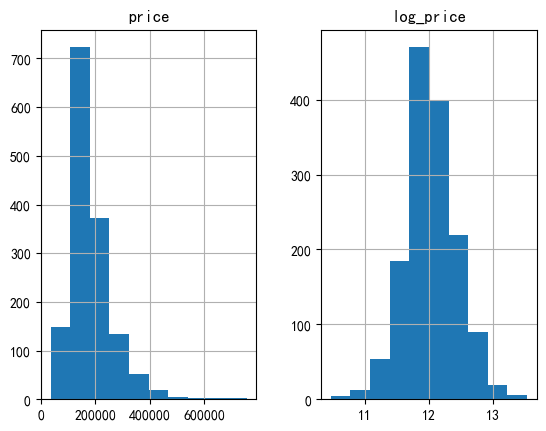

In [24]:
# 查看房价分布，发现不平滑，需要对价格进行对数变换
prices = pd.DataFrame({'price':train_df['SalePrice'], 'log_price':np.log1p(train_df['SalePrice'])})
prices.hist()

In [25]:
y_train = np.log1p(train_df.pop('SalePrice')) # 从数据集中删除SalePrice列，并对SalePrice进行log处理并保存到y_train变量中

In [26]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


#### 拼接训练集和测试集

In [27]:
# 查看数据集形状，为下一步拼接做准备
print('训练集形状：', train_df.shape,'测试集形状：', test_df.shape)

训练集形状： (1460, 79) 测试集形状： (1459, 79)


In [28]:
# 纵向拼接训练集和测试集，为下一步对非数值类型特征进行编码做准备
all_df = pd.concat((train_df,test_df),axis=0)

In [29]:
all_df.shape

(2919, 79)

#### 对变量类型进行转换

In [30]:
# MSSubClass为整数类型，但实际上它是分类变量，需要进行转换
all_df['MSSubClass'].dtypes

dtype('int64')

In [31]:
# 转换数据类型
all_df['MSSubClass'] = all_df['MSSubClass'].astype('str')

In [32]:
all_df['MSSubClass'].dtypes

dtype('O')

In [33]:
all_df['MSSubClass'].value_counts() # 统计各个MSSubClass的数量

MSSubClass
20     1079
60      575
50      287
120     182
30      139
70      128
160     128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64

#### 对非数值列进行编码

In [34]:
# one-hot encoding
pd.get_dummies(all_df['MSSubClass'])

,120,150,160,180,190,20,30,40,45,50,60,70,75,80,85,90
Id,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2916,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2917,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [35]:
# 对所有非数值列进行one-hot处理，get_dummies()函数会自动判断哪些列是非数值列，对空值的编码为全部填0，并返回一个新的DataFrame。
all_dummy_df = pd.get_dummies(all_df) 

In [36]:
all_dummy_df.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,...,False,False,False,True,False,False,False,False,True,False
2,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,...,False,False,False,True,False,False,False,False,True,False
3,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,...,False,False,False,True,False,False,False,False,True,False
4,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,...,False,False,False,True,True,False,False,False,False,False
5,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,...,False,False,False,True,False,False,False,False,True,False


#### 处理缺失值

In [37]:
# 查看缺失值最多的10个特征
all_dummy_df.isnull().sum().sort_values(ascending=False).head(10)

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
BsmtUnfSF         1
GarageArea        1
TotalBsmtSF       1
GarageCars        1
BsmtFinSF2        1
dtype: int64

In [38]:
mean_cols = all_dummy_df.mean()
mean_cols

LotFrontage                 69.305795
LotArea                  10168.114080
OverallQual                  6.089072
OverallCond                  5.564577
YearBuilt                 1971.312778
                             ...     
SaleCondition_AdjLand        0.004111
SaleCondition_Alloca         0.008222
SaleCondition_Family         0.015759
SaleCondition_Normal         0.822885
SaleCondition_Partial        0.083933
Length: 302, dtype: float64

In [39]:
all_dummy_df = all_dummy_df.fillna(mean_cols)
all_dummy_df.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,...,False,False,False,True,False,False,False,False,True,False
2,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,...,False,False,False,True,False,False,False,False,True,False
3,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,...,False,False,False,True,False,False,False,False,True,False
4,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,...,False,False,False,True,True,False,False,False,False,False
5,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,...,False,False,False,True,False,False,False,False,True,False


In [40]:
all_dummy_df.isnull().sum().sum()

0

#### 标准化数据

In [41]:
numeric_cols = all_df.columns[all_df.dtypes!= 'object']
numeric_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [42]:
numeric_col_means = all_dummy_df.loc[:, numeric_cols].mean() # 数值列的均值
numeric_col_means

LotFrontage         69.305795
LotArea          10168.114080
OverallQual          6.089072
OverallCond          5.564577
YearBuilt         1971.312778
YearRemodAdd      1984.264474
MasVnrArea         102.201312
BsmtFinSF1         441.423235
BsmtFinSF2          49.582248
BsmtUnfSF          560.772104
TotalBsmtSF       1051.777587
1stFlrSF          1159.581706
2ndFlrSF           336.483727
LowQualFinSF         4.694416
GrLivArea         1500.759849
BsmtFullBath         0.429894
BsmtHalfBath         0.061364
FullBath             1.568003
HalfBath             0.380267
BedroomAbvGr         2.860226
KitchenAbvGr         1.044536
TotRmsAbvGrd         6.451524
Fireplaces           0.597122
GarageYrBlt       1978.113406
GarageCars           1.766621
GarageArea         472.874572
WoodDeckSF          93.709832
OpenPorchSF         47.486811
EnclosedPorch       23.098321
3SsnPorch            2.602261
ScreenPorch         16.062350
PoolArea             2.251799
MiscVal             50.825968
MoSold    

In [43]:
numeric_col_std = all_dummy_df.loc[:, numeric_cols].std() # 计算数值列的标准差
numeric_col_std

LotFrontage        21.312345
LotArea          7886.996359
OverallQual         1.409947
OverallCond         1.113131
YearBuilt          30.291442
YearRemodAdd       20.894344
MasVnrArea        178.626089
BsmtFinSF1        455.532750
BsmtFinSF2        169.176615
BsmtUnfSF         439.468337
TotalBsmtSF       440.690726
1stFlrSF          392.362079
2ndFlrSF          428.701456
LowQualFinSF       46.396825
GrLivArea         506.051045
BsmtFullBath        0.524556
BsmtHalfBath        0.245603
FullBath            0.552969
HalfBath            0.502872
BedroomAbvGr        0.822693
KitchenAbvGr        0.214462
TotRmsAbvGrd        1.569379
Fireplaces          0.646129
GarageYrBlt        24.867762
GarageCars          0.761494
GarageArea        215.357904
WoodDeckSF        126.526589
OpenPorchSF        67.575493
EnclosedPorch      64.244246
3SsnPorch          25.188169
ScreenPorch        56.184365
PoolArea           35.663946
MiscVal           567.402211
MoSold              2.714762
YrSold        

In [44]:
all_dummy_df.loc[:,numeric_cols] = (all_dummy_df.loc[:,numeric_cols] - numeric_col_means)/numeric_col_std

In [45]:
all_dummy_df.loc[:,numeric_cols]

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
Id,,,,,,,,,,,,,,,,,,,,,
1,-0.202033,-0.217841,0.646073,-0.507197,1.046078,0.896679,0.525112,0.580807,-0.29308,-0.934702,...,0.348840,-0.740634,0.199972,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,-1.551918,0.157619
2,0.501785,-0.072032,-0.063174,2.187904,0.154737,-0.395536,-0.572152,1.177910,-0.29308,-0.629788,...,-0.059782,1.614603,-0.702722,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,-0.446848,-0.602858
3,-0.061269,0.137173,0.646073,-0.507197,0.980053,0.848819,0.334770,0.097856,-0.29308,-0.288467,...,0.627446,-0.740634,-0.081195,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,1.026577,0.157619
4,-0.436639,-0.078371,0.646073,-0.507197,-1.859033,-0.682695,-0.572152,-0.494856,-0.29308,-0.047266,...,0.785323,-0.740634,-0.184783,3.874303,-0.103313,-0.285886,-0.063139,-0.089577,-1.551918,-1.363335
5,0.689469,0.518814,1.355319,-0.507197,0.947040,0.753100,1.387248,0.468851,-0.29308,-0.161040,...,1.686149,0.776834,0.540332,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,2.131647,0.157619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,-2.266564,-1.043758,-1.481667,1.289537,-0.043338,-0.682695,-0.572152,-0.969026,-0.29308,-0.033614,...,-2.195761,-0.740634,-0.702722,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,-0.078492,-1.363335
2916,-2.266564,-1.049083,-1.481667,-0.507197,-0.043338,-0.682695,-0.572152,-0.415828,-0.29308,-0.607034,...,-0.867740,-0.740634,-0.347564,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,-0.815205,-1.363335
2917,4.255477,1.246594,-0.772420,1.289537,-0.373465,0.561660,-0.572152,1.717937,-0.29308,-1.276024,...,0.478856,3.005615,-0.702722,-0.359539,-0.103313,-0.285886,-0.063139,-0.089577,1.026577,-1.363335


#### 划分数据集

In [46]:
dummy_train_df = all_dummy_df.loc[train_df.index]
dummy_train_df

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,-0.202033,-0.217841,0.646073,-0.507197,1.046078,0.896679,0.525112,0.580807,-0.293080,-0.934702,...,False,False,False,True,False,False,False,False,True,False
2,0.501785,-0.072032,-0.063174,2.187904,0.154737,-0.395536,-0.572152,1.177910,-0.293080,-0.629788,...,False,False,False,True,False,False,False,False,True,False
3,-0.061269,0.137173,0.646073,-0.507197,0.980053,0.848819,0.334770,0.097856,-0.293080,-0.288467,...,False,False,False,True,False,False,False,False,True,False
4,-0.436639,-0.078371,0.646073,-0.507197,-1.859033,-0.682695,-0.572152,-0.494856,-0.293080,-0.047266,...,False,False,False,True,True,False,False,False,False,False
5,0.689469,0.518814,1.355319,-0.507197,0.947040,0.753100,1.387248,0.468851,-0.293080,-0.161040,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,-0.342796,-0.285421,-0.063174,-0.507197,0.914028,0.753100,-0.572152,-0.969026,-0.293080,0.892505,...,False,False,False,True,False,False,False,False,True,False
1457,0.736390,0.381246,-0.063174,0.391170,0.220763,0.178782,0.094044,0.765207,0.670410,0.064232,...,False,False,False,True,False,False,False,False,True,False
1458,-0.155112,-0.142781,0.646073,3.086271,-1.000704,1.040259,-0.572152,-0.365338,-0.293080,0.719569,...,False,False,False,True,False,False,False,False,True,False


In [47]:
dummy_test_df = all_dummy_df.loc[test_df.index]
dummy_test_df

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1461,0.501785,0.184340,-0.772420,0.391170,-0.340452,-1.113434,-0.572152,0.058342,0.558102,-0.661645,...,False,False,False,True,False,False,False,False,True,False
1462,0.548706,0.519702,-0.063174,0.391170,-0.439490,-1.257014,0.032463,1.057173,-0.293080,-0.352180,...,False,False,False,True,False,False,False,False,True,False
1463,0.220258,0.464294,-0.772420,-0.507197,0.848003,0.657380,-0.572152,0.767402,-0.293080,-0.964284,...,False,False,False,True,False,False,False,False,True,False
1464,0.407942,-0.024105,-0.063174,0.391170,0.881015,0.657380,-0.460186,0.352503,-0.293080,-0.538769,...,False,False,False,True,False,False,False,False,True,False
1465,-1.234298,-0.654636,1.355319,-0.507197,0.682939,0.370221,-0.572152,-0.391680,-0.293080,1.038136,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,-2.266564,-1.043758,-1.481667,1.289537,-0.043338,-0.682695,-0.572152,-0.969026,-0.293080,-0.033614,...,False,False,False,True,False,False,False,False,True,False
2916,-2.266564,-1.049083,-1.481667,-0.507197,-0.043338,-0.682695,-0.572152,-0.415828,-0.293080,-0.607034,...,False,False,False,True,True,False,False,False,False,False
2917,4.255477,1.246594,-0.772420,1.289537,-0.373465,0.561660,-0.572152,1.717937,-0.293080,-1.276024,...,False,False,False,True,True,False,False,False,False,False


#### 模型训练

##### 岭回归

In [48]:
# 划分数据集
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
X_train = dummy_train_df.values
X_test = dummy_test_df.values
y_train = y_train.values

In [49]:
# 网格搜索
alphas = np.logspace(-3, 2, 50)

In [50]:
test_scores = []

In [51]:
from sklearn.model_selection import cross_val_score
for alpha in alphas:
    clf = Ridge(alpha=alpha)
    test_score = np.sqrt(-cross_val_score(clf, X_train, y_train, cv=10, scoring='neg_mean_squared_error'))
    test_scores.append(test_score.mean())

In [52]:
test_scores

[0.15327967052111185,
 0.1532503875275893,
 0.15321608905791415,
 0.15317399479115806,
 0.15312138698742994,
 0.15305568124860924,
 0.15297441932771466,
 0.15287519772540273,
 0.15275554655984536,
 0.1526127762404283,
 0.15244381875556354,
 0.15224510249939252,
 0.15201250661022847,
 0.15174143661161152,
 0.1514270476010092,
 0.15106461809601898,
 0.15065004856526665,
 0.1501804214611237,
 0.1496545155206625,
 0.14907313152044205,
 0.14843909076685732,
 0.14775684325977267,
 0.14703177255930905,
 0.1462694560736098,
 0.14547522969289153,
 0.1446543188250729,
 0.14381253146656192,
 0.14295719295909484,
 0.14209783146292945,
 0.14124621717268834,
 0.14041566356616683,
 0.13961982557043767,
 0.13887139349192165,
 0.1381810341855439,
 0.1375567673832684,
 0.13700381662891686,
 0.13652489663320547,
 0.13612085891827294,
 0.13579156614286989,
 0.13553680274949148,
 0.13535700158299316,
 0.13525361328027835,
 0.1352290623427413,
 0.1352863727196391,
 0.1354286472959797,
 0.13565861290095876,


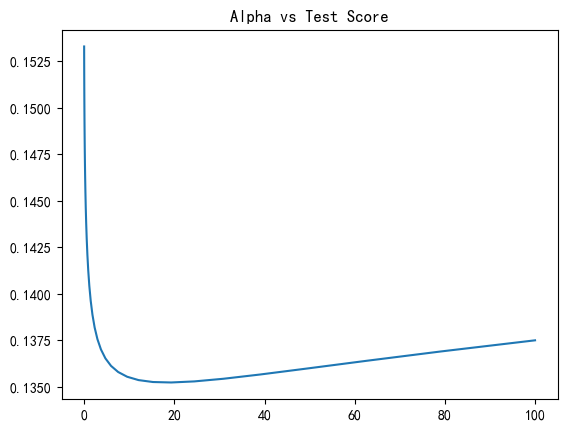

In [53]:
import matplotlib.pyplot as plt
plt.plot(alphas, test_scores)
plt.title("Alpha vs Test Score")
plt.show()

In [54]:
ridge = Ridge(alpha=17)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

In [55]:
y_pred2 = np.expm1(y_pred)
y_pred2

array([113342.07481779, 148927.20671963, 170306.73023878, ...,
       159271.4209774 , 112520.46302475, 224787.00980434])

##### K-近邻算法

In [56]:
# 划分数据集
from sklearn.neighbors import KNeighborsRegressor  # 改为回归器
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X = dummy_train_df.values
y = y_train
X_train, X_test, k_y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 建立模型
X_test1 = dummy_test_df.values
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# 1. 定义模型
knn_reg = KNeighborsRegressor()

# 2. 定义超参数网格
param_grid = {
    'n_neighbors': [3, 5, 7, 9],      # 邻居数量
    'weights': ['uniform', 'distance'],  # 权重计算方式
    'metric': ['euclidean', 'manhattan']  # 距离度量
}

# 3. 自定义评分指标（可选）
scorers = {
    'r2': 'r2',                       # R²分数
    'neg_mse': make_scorer(mean_squared_error, greater_is_better=False)
}

# 4. 初始化网格搜索
grid_search = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_grid,
    scoring=scorers,
    refit='r2',                       # 最终用R²选择最佳模型
    cv=5,                             # 5折交叉验证
    verbose=1                         # 打印进度
)

# 5. 执行搜索
grid_search.fit(X_train, k_y_train)

# 6. 输出最佳参数和得分
print("最佳参数:", grid_search.best_params_)
print("最佳R²分数:", grid_search.best_score_)

# 7. 使用最佳模型预测
best_knn = grid_search.best_estimator_
test_score = best_knn.score(X_test, y_test)
print("测试集R²分数:", test_score)
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train, k_y_train)
score = knn_reg.score(X_train, k_y_train)  # 返回R²分数
print("模型得分:", score)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
最佳参数: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
最佳R²分数: 0.8184334445291782
测试集R²分数: 0.82526413692661
模型得分: 0.9035820395102799
最佳参数: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
最佳R²分数: 0.8184334445291782
测试集R²分数: 0.82526413692661
模型得分: 0.9035820395102799


In [57]:
knn_reg.fit(X_train, k_y_train)
score = knn_reg.score(X_train, k_y_train)  # 返回R²分数
print("模型得分:", score)

模型得分: 0.9035820395102799


##### 决策树回归

In [58]:
# 划分数据集
from sklearn.tree import DecisionTreeRegressor  # 改为决策树回归器
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

# 数据准备（假设已加载）
X = dummy_train_df.values
y = y_train
X_train, X_test, t_y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test1 = dummy_test_df.values

# 1. 定义决策树回归模型
dt_reg = DecisionTreeRegressor(random_state=42)

# 2. 定义超参数网格
param_grid = {
    'max_depth': [3, 5, 7, None],      # 树的最大深度（None表示不限制）
    'min_samples_split': [2, 5, 10],    # 分裂所需最小样本数
    'min_samples_leaf': [1, 2, 4],      # 叶节点最小样本数
    'criterion': ['squared_error', 'friedman_mse']  # 分裂标准
}

# 3. 初始化网格搜索
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
    refit='r2',                       # 用R²选择最佳模型
    cv=5,                             # 5折交叉验证
    verbose=1                         # 打印进度
)

# 4. 执行网格搜索
grid_search.fit(X_train, t_y_train)

# 5. 输出最佳参数和得分
print("最佳参数:", grid_search.best_params_)
print("最佳R²分数:", grid_search.best_score_)

# 6. 使用最佳模型预测
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
print("\n测试集评估:")
print(f"R²分数: {test_r2:.4f}")
print(f"均方误差(MSE): {test_mse:.4f}")

# 7. 训练最终模型（可选）
final_dt = DecisionTreeRegressor(**grid_search.best_params_, random_state=42)
final_dt.fit(X_train, t_y_train)
print("\n最终模型训练集R²:", final_dt.score(X_train, t_y_train))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
最佳参数: {'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
最佳R²分数: 0.7521621225307774

测试集评估:
R²分数: 0.7839
均方误差(MSE): 0.0403

最终模型训练集R²: 0.9523647828989655
最佳参数: {'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
最佳R²分数: 0.7521621225307774

测试集评估:
R²分数: 0.7839
均方误差(MSE): 0.0403

最终模型训练集R²: 0.9523647828989655


##### 支持向量机回归

In [59]:
# 划分数据集
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

# 数据准备（假设已加载）
X = dummy_train_df.values
y = y_train
X_train, X_test, t_y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test1 = dummy_test_df.values

svc = SVR(kernel='linear')
svc.fit(X_train, t_y_train)
y_pred = svc.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)



MSE: 0.01844809816378481
R2: 0.9011414156086349


#### 特征重要性分析与可视化

In [70]:
# 使用多种方法分析特征重要性
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体 - 修复字体显示问题
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
X_full = dummy_train_df.values
y_full = y_train  # y_train已经是numpy数组，无需调用.values
feature_names = dummy_train_df.columns.tolist()

print(f"总特征数量: {len(feature_names)}")
print(f"数据形状: {X_full.shape}")

# 方法1: 随机森林特征重要性
print("\n=== 计算随机森林特征重要性 ===")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_full, y_full)
rf_importance = rf_model.feature_importances_

# 方法2: 岭回归系数绝对值
print("=== 计算岭回归特征重要性 ===")
ridge_model = Ridge(alpha=17, random_state=42)
ridge_model.fit(X_full, y_full)
ridge_importance = np.abs(ridge_model.coef_)

# 方法3: 单变量统计检验 (F-score)
print("=== 计算F-score特征重要性 ===")
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_full, y_full)
f_scores = selector.scores_

# 创建特征重要性DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_importance,
    'ridge_importance': ridge_importance / np.max(ridge_importance),  # 标准化
    'f_score': f_scores / np.max(f_scores)  # 标准化
})

# 计算综合重要性得分（平均值）
importance_df['combined_score'] = (
    importance_df['rf_importance'] + 
    importance_df['ridge_importance'] + 
    importance_df['f_score']
) / 3

# 排序并获取前20个特征
top_20_features = importance_df.sort_values('combined_score', ascending=False).head(20)
print("\n=== 前20个最重要特征 ===")
print(top_20_features[['feature', 'combined_score']].to_string(index=False))

总特征数量: 302
数据形状: (1460, 302)

=== 计算随机森林特征重要性 ===
=== 计算岭回归特征重要性 ===
=== 计算F-score特征重要性 ===

=== 前20个最重要特征 ===
             feature  combined_score
         OverallQual        0.754252
           GrLivArea        0.369761
    MSZoning_C (all)        0.340558
          GarageCars        0.286193
Neighborhood_Crawfor        0.240730
    RoofMatl_ClyTile        0.237720
Neighborhood_StoneBr        0.237053
Neighborhood_NridgHt        0.231769
Neighborhood_Edwards        0.212295
           YearBuilt        0.204304
            1stFlrSF        0.200988
         BsmtQual_Ex        0.182075
     Condition2_PosN        0.174008
      MSSubClass_160        0.171275
Neighborhood_NoRidge        0.170402
      KitchenQual_Ex        0.166705
            FullBath        0.166151
Neighborhood_MeadowV        0.164394
 Exterior1st_BrkFace        0.158372
          GarageArea        0.158146
=== 计算岭回归特征重要性 ===
=== 计算F-score特征重要性 ===

=== 前20个最重要特征 ===
             feature  combined_score
         Overa

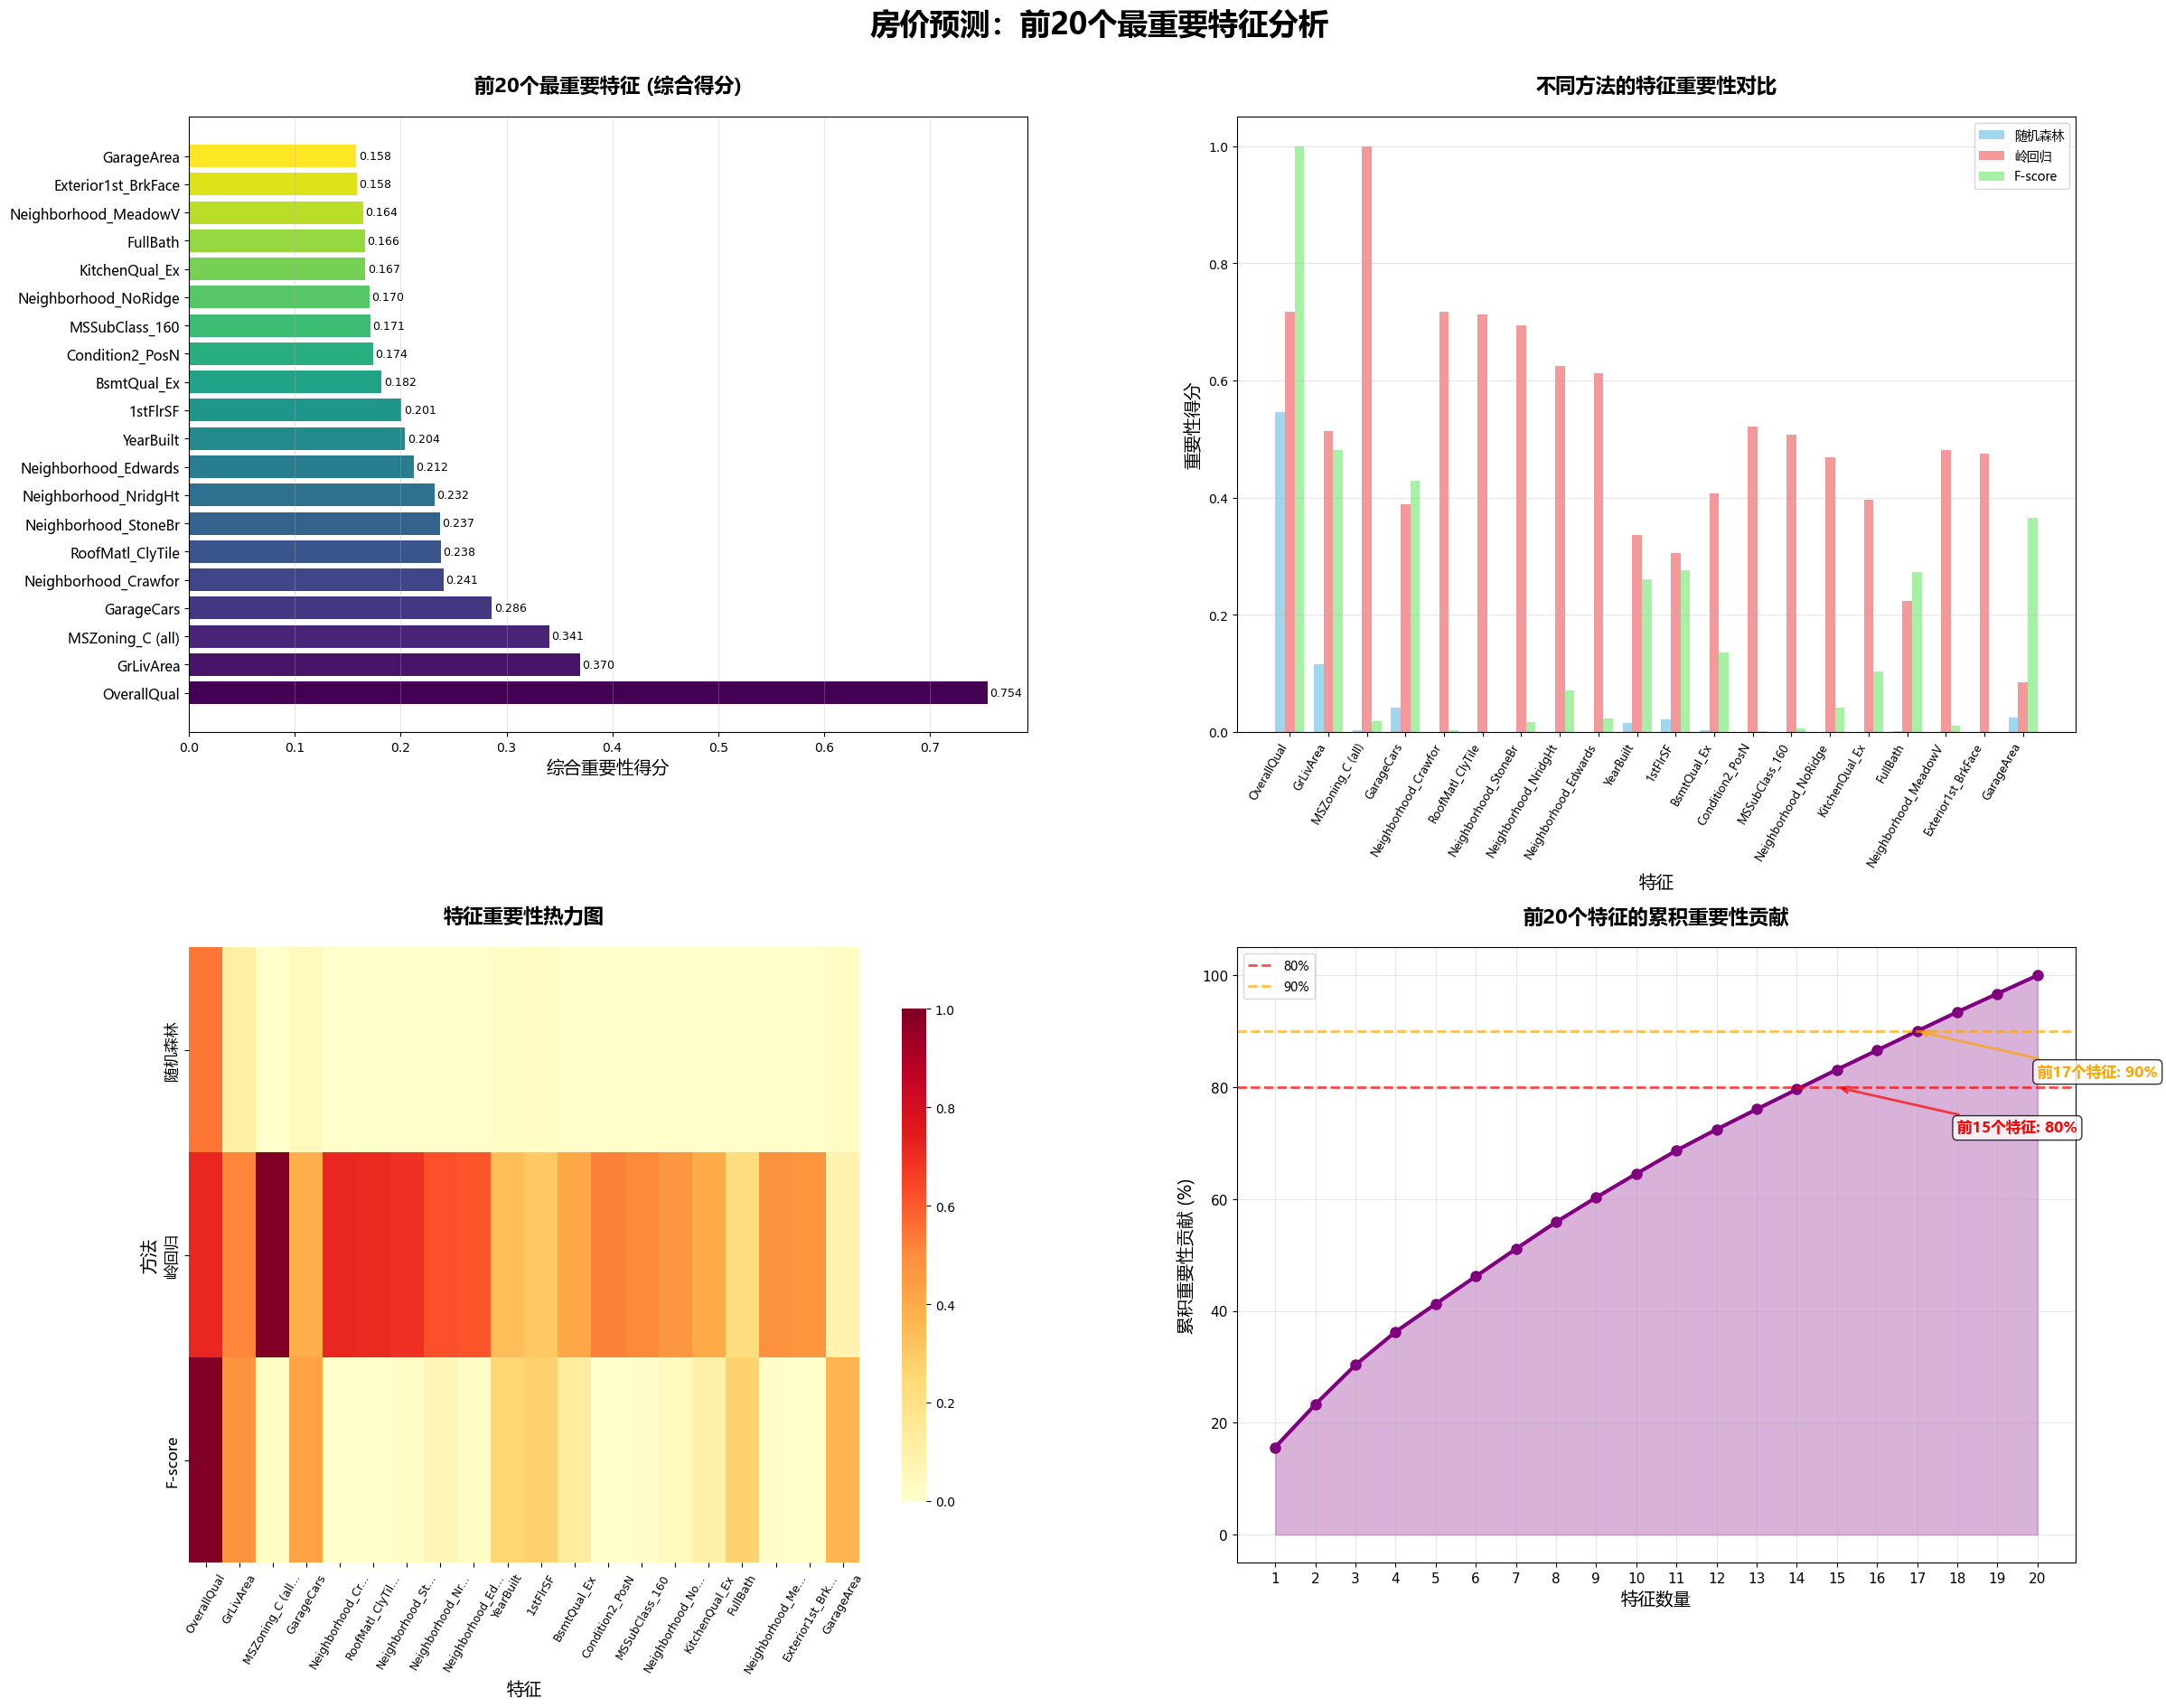


=== 特征重要性统计 ===
前5个特征累积贡献: 41.3%
前10个特征累积贡献: 64.5%
前15个特征累积贡献: 83.1%
前20个特征累积贡献: 100.0%


In [71]:
# 可视化前20个最重要特征
# 重新设置字体确保中文显示
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(24, 20))  # 增大图表尺寸
fig.suptitle('房价预测：前20个最重要特征分析', fontsize=24, fontweight='bold', y=0.98, fontfamily='Microsoft YaHei')

# 1. 综合特征重要性柱状图
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, 20))
bars1 = ax1.barh(range(20), top_20_features['combined_score'], color=colors)
ax1.set_yticks(range(20))
ax1.set_yticklabels(top_20_features['feature'], fontsize=11, fontfamily='Microsoft YaHei')  # 增大字体
ax1.set_xlabel('综合重要性得分', fontsize=14, fontfamily='Microsoft YaHei')
ax1.set_title('前20个最重要特征 (综合得分)', fontsize=16, fontweight='bold', pad=20, fontfamily='Microsoft YaHei')
ax1.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 2. 不同方法的特征重要性对比
ax2 = axes[0, 1]
x_pos = np.arange(len(top_20_features))
width = 0.25

bars1 = ax2.bar(x_pos - width, top_20_features['rf_importance'], width, 
                label='随机森林', alpha=0.8, color='skyblue')
bars2 = ax2.bar(x_pos, top_20_features['ridge_importance'], width, 
                label='岭回归', alpha=0.8, color='lightcoral')
bars3 = ax2.bar(x_pos + width, top_20_features['f_score'], width, 
                label='F-score', alpha=0.8, color='lightgreen')

ax2.set_xlabel('特征', fontsize=14, fontfamily='Microsoft YaHei')
ax2.set_ylabel('重要性得分', fontsize=14, fontfamily='Microsoft YaHei')
ax2.set_title('不同方法的特征重要性对比', fontsize=16, fontweight='bold', pad=20, fontfamily='Microsoft YaHei')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_20_features['feature'], rotation=60, ha='right', fontsize=9, fontfamily='Microsoft YaHei')  # 调整旋转角度
ax2.legend(fontsize=12, prop={'family': 'Microsoft YaHei'})
ax2.grid(axis='y', alpha=0.3)
# 调整底部边距以显示完整的标签
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=60, ha='right')

# 3. 特征重要性热力图
ax3 = axes[1, 0]
heatmap_data = top_20_features[['rf_importance', 'ridge_importance', 'f_score']].T
# 截断特征名称以避免过长
feature_labels = [name[:15] + '...' if len(name) > 15 else name for name in top_20_features['feature']]
sns.heatmap(heatmap_data, 
            xticklabels=feature_labels, 
            yticklabels=['随机森林', '岭回归', 'F-score'],
            annot=False, cmap='YlOrRd', cbar=True, ax=ax3,
            cbar_kws={'shrink': 0.8})
ax3.set_title('特征重要性热力图', fontsize=16, fontweight='bold', pad=20, fontfamily='Microsoft YaHei')
ax3.set_xlabel('特征', fontsize=14, fontfamily='Microsoft YaHei')
ax3.set_ylabel('方法', fontsize=14, fontfamily='Microsoft YaHei')
ax3.tick_params(axis='x', rotation=60, labelsize=9)
ax3.tick_params(axis='y', labelsize=12)
# 设置热力图的y轴标签字体
for label in ax3.get_yticklabels():
    label.set_fontfamily('Microsoft YaHei')

# 4. 累积重要性贡献
ax4 = axes[1, 1]
cumulative_importance = np.cumsum(top_20_features['combined_score'])
cumulative_percentage = (cumulative_importance / cumulative_importance.max()) * 100

ax4.plot(range(1, 21), cumulative_percentage, 'o-', linewidth=3, markersize=8, color='purple')
ax4.fill_between(range(1, 21), cumulative_percentage, alpha=0.3, color='purple')
ax4.set_xlabel('特征数量', fontsize=14, fontfamily='Microsoft YaHei')
ax4.set_ylabel('累积重要性贡献 (%)', fontsize=14, fontfamily='Microsoft YaHei')
ax4.set_title('前20个特征的累积重要性贡献', fontsize=16, fontweight='bold', pad=20, fontfamily='Microsoft YaHei')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(1, 21))
ax4.tick_params(axis='both', labelsize=11)

# 添加重要的里程碑线
ax4.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80%', linewidth=2)
ax4.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%', linewidth=2)
ax4.legend(fontsize=12, prop={'family': 'Microsoft YaHei'})

# 在图上标注前几个特征达到80%和90%的位置
for threshold, color in [(80, 'red'), (90, 'orange')]:
    idx = np.where(cumulative_percentage >= threshold)[0]
    if len(idx) > 0:
        first_idx = idx[0] + 1
        ax4.annotate(f'前{first_idx}个特征: {threshold}%', 
                    xy=(first_idx, threshold), xytext=(first_idx+3, threshold-8),
                    arrowprops=dict(arrowstyle='->', color=color, alpha=0.7, lw=2),
                    fontsize=12, color=color, fontweight='bold',
                    fontfamily='Microsoft YaHei',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# 调整子图间距
plt.subplots_adjust(left=0.08, bottom=0.12, right=0.95, top=0.92, wspace=0.25, hspace=0.35)
plt.show()

# 输出特征重要性统计信息 - 修复索引问题
cumulative_percentage_list = cumulative_percentage.values if hasattr(cumulative_percentage, 'values') else cumulative_percentage
print(f"\n=== 特征重要性统计 ===")
print(f"前5个特征累积贡献: {cumulative_percentage_list[4]:.1f}%")
print(f"前10个特征累积贡献: {cumulative_percentage_list[9]:.1f}%")
print(f"前15个特征累积贡献: {cumulative_percentage_list[14]:.1f}%")
print(f"前20个特征累积贡献: {cumulative_percentage_list[19]:.1f}%")

In [72]:
# 创建详细的特征重要性分析表格
print("\n" + "="*80)
print("详细特征重要性分析报告".center(80))
print("="*80)

# 显示前20个特征的详细信息
display_df = top_20_features.copy()
display_df.index = range(1, 21)
display_df.columns = ['特征名称', '随机森林重要性', '岭回归重要性', 'F-score重要性', '综合得分']

# 格式化数值显示
for col in ['随机森林重要性', '岭回归重要性', 'F-score重要性', '综合得分']:
    display_df[col] = display_df[col].round(4)

print("\n📊 前20个最重要特征排名:")
print(display_df.to_string())

# 分析特征类型
print(f"\n🔍 特征类型分析:")
feature_types = {}
for feature in top_20_features['feature']:
    if any(x in feature.lower() for x in ['area', 'sf', 'lot']):
        feature_types[feature] = '面积相关'
    elif any(x in feature.lower() for x in ['qual', 'quality']):
        feature_types[feature] = '质量相关'
    elif any(x in feature.lower() for x in ['year', 'age']):
        feature_types[feature] = '时间相关'
    elif any(x in feature.lower() for x in ['garage', 'basement', 'kitchen']):
        feature_types[feature] = '房屋设施'
    elif any(x in feature.lower() for x in ['neighborhood', 'zone']):
        feature_types[feature] = '位置相关'
    else:
        feature_types[feature] = '其他'

type_counts = pd.Series(list(feature_types.values())).value_counts()
print("\n特征类型分布:")
for ftype, count in type_counts.items():
    print(f"  {ftype}: {count}个特征")

# 关键发现 - 修复索引问题
cumulative_percentage_list = cumulative_percentage.values if hasattr(cumulative_percentage, 'values') else cumulative_percentage
print(f"\n💡 关键发现:")
top_5 = top_20_features.head(5)
print(f"1. 最重要的5个特征贡献了 {cumulative_percentage_list[4]:.1f}% 的重要性")
print(f"2. 最重要特征: {top_5.iloc[0]['feature']} (得分: {top_5.iloc[0]['combined_score']:.4f})")
print(f"3. 前20个特征覆盖了主要的房价影响因素")

# 建议
print(f"\n📋 建议:")
print("1. 可以使用前10-15个特征进行模型简化，仍能保持较好性能")
print("2. 重点关注面积、质量、位置相关的特征")
print("3. 可以考虑特征工程来进一步提升这些重要特征的表达能力")


                                  详细特征重要性分析报告                                   

📊 前20个最重要特征排名:
                    特征名称  随机森林重要性  岭回归重要性  F-score重要性    综合得分
1            OverallQual   0.5458  0.7170      1.0000  0.7543
2              GrLivArea   0.1151  0.5138      0.4805  0.3698
3       MSZoning_C (all)   0.0034  1.0000      0.0183  0.3406
4             GarageCars   0.0411  0.3882      0.4294  0.2862
5   Neighborhood_Crawfor   0.0007  0.7177      0.0038  0.2407
6       RoofMatl_ClyTile   0.0000  0.7132      0.0000  0.2377
7   Neighborhood_StoneBr   0.0001  0.6933      0.0177  0.2371
8   Neighborhood_NridgHt   0.0001  0.6250      0.0703  0.2318
9   Neighborhood_Edwards   0.0007  0.6129      0.0233  0.2123
10             YearBuilt   0.0157  0.3363      0.2609  0.2043
11              1stFlrSF   0.0220  0.3055      0.2755  0.2010
12           BsmtQual_Ex   0.0024  0.4074      0.1365  0.1821
13       Condition2_PosN   0.0000  0.5211      0.0009  0.1740
14        MSSubClass_160   0.0001 